In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_172 = pd.read_excel('All_GS_172-2.xlsx')
df_j5= pd.read_excel('All-J5 .xlsx')
df_j7a=pd.read_excel('All-J7A.xlsx')

In [3]:
df_172= df_172.iloc[:,[0,1,2]]
df_j5= df_j5.iloc[:,[0,1,2]]
df_j7a= df_j7a.iloc[:,[0,1,2]]


In [7]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_172, "GS-172"),
    (df_j5, "J5"),
    (df_j7a, "J7A")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
GS-172       | 5000.00    | 5150.00    | 150.00          | 150     
J5           | 5000.00    | 5150.00    | 150.00          | 150     
J7A          | 5000.00    | 5150.00    | 150.00          | 150     


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [11]:
# Standardize the NPHI for your 3 existing dataframes
nphi_172 = scaler.fit_transform(df_172[['Neutron Porosity']].values).flatten()
nphi_j7a = scaler.fit_transform(df_j7a[['Neutron Porosity']].values).flatten()
nphi_j5 = scaler.fit_transform(df_j5[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_172_j7a = dtw_sakoe_chiba(nphi_172, nphi_j7a, int(0.15 * max(len(nphi_172), len(nphi_j7a))))
dist_nphi_j7a_j5 = dtw_sakoe_chiba(nphi_j7a, nphi_j5, int(0.15 * max(len(nphi_j7a), len(nphi_j5))))
dist_nphi_j5_172 = dtw_sakoe_chiba(nphi_j5, nphi_172, int(0.15 * max(len(nphi_j5), len(nphi_172))))

print(f"NPHI Distance 172-J7a: {dist_nphi_172_j7a:.2f}")
print(f"NPHI Distance J7A-J5: {dist_nphi_j7a_j5:.2f}")
print(f"NPHI Distance J5-172: {dist_nphi_j5_172:.2f}")



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_172= scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j7a = scaler.fit_transform(df_j7a[['GR (API)']].values).flatten()
gr_j5 = scaler.fit_transform(df_j5[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_172_j7a = dtw_sakoe_chiba(gr_172, gr_j7a, int(0.15 * max(len(gr_172), len(gr_j7a))))

# J6A to J4
dist_gr_j7a_j5 = dtw_sakoe_chiba(gr_j7a, gr_j5, int(0.15 * max(len(gr_j7a), len(gr_j5))))

# J4 to NO159-2
dist_gr_j5_172 = dtw_sakoe_chiba(gr_j5, gr_172, int(0.15 * max(len(gr_j5), len(gr_172))))

print(f"GR Distance 179-J7A: {dist_gr_172_j7a:.2f}")
print(f"GR Distance J7A-J5: {dist_gr_j7a_j5:.2f}")
print(f"GR Distance J5-179: {dist_gr_j5_172:.2f}")

NPHI Distance 172-J7a: 82.75
NPHI Distance J7A-J5: 79.81
NPHI Distance J5-172: 82.23
GR Distance 179-J7A: 84.07
GR Distance J7A-J5: 77.45
GR Distance J5-179: 87.17


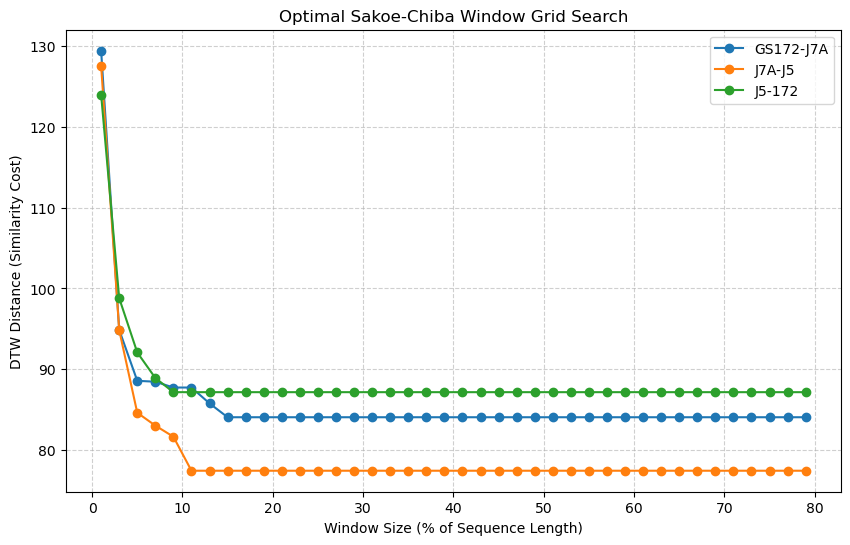

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_172 = scaler.fit_transform(df_172[['GR (API)']].values).flatten()
gr_j7a = scaler.fit_transform(df_j7a[['GR (API)']].values).flatten()
gr_j5 = scaler.fit_transform(df_j5[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_172, gr_j7a, "GS172-J7A"), (gr_j7a, gr_j5, "J7A-J5"), (gr_j5, gr_172, "J5-172")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

# 4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [15]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)
    # Find the index of the first time that minimum was reached
    best_index = distance_list.index(min_dist)
    # Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_172_j7a = get_best_window(window_percents.tolist(), all_results["GS172-J7A"])
best_j7a_j5 = get_best_window(window_percents.tolist(), all_results["J7A-J5"])
best_j5_172 = get_best_window(window_percents.tolist(), all_results["J5-172"])

print(f"Optimal Window for 172-J7A: {best_172_j7a}%")
print(f"Optimal Window for J7A-J5: {best_j7a_j5}%")
print(f"Optimal Window for J5-172: {best_j5_172}%")

Optimal Window for 172-J7A: 15%
Optimal Window for J7A-J5: 11%
Optimal Window for J5-172: 9%


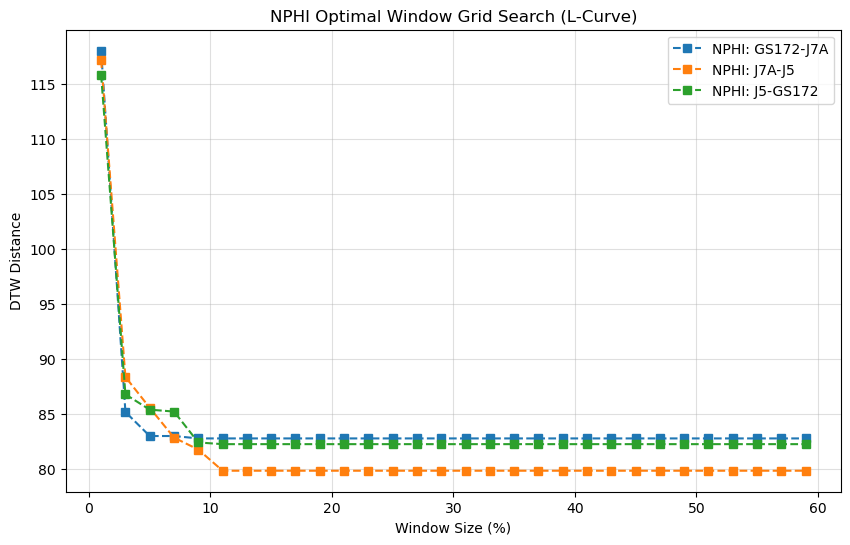

--- Optimized NPHI Windows ---
GS172-J7A: 5%
J7A-J5:    11%
J5-172:  9%


In [17]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_172, nphi_j7a, "GS172-J7A"), 
    (nphi_j7a, nphi_j5, "J7A-J5"), 
    (nphi_j5, nphi_172, "J5-GS172")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_172_j7a = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["GS172-J7A"])
best_nphi_j7a_j5 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J7A-J5"])
best_nphi_j5_172 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J5-GS172"])

print(f"--- Optimized NPHI Windows ---")
print(f"GS172-J7A: {best_nphi_172_j7a}%")
print(f"J7A-J5:    {best_nphi_j7a_j5}%")
print(f"J5-172:  {best_nphi_j5_172}%")

## L Curve

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,
    "axes.titlesize": 34,
    "legend.fontsize": 30,
    "figure.figsize": (18, 18),
    "axes.linewidth": 2.0
})
def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [26]:
import matplotlib.pyplot as plt

'''def plot_research_l_curve(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    fig, ax = plt.subplots()  # uses your rcParams size (18x18)

# Main curve
    ax.plot(window_percents, distances, marker='o', ms=12, 
            lw=5, color='#1f77b4', label='DTW Cost (GR)')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=400, marker='*', zorder=10)
    
    # Annotation (same style)
    ax.annotate(f'Optimum Window: {best_window}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    ax.set_title(f'Optimization: {label} ({log_name})', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)

# --- PLOT GR CURVES ---
# --- PLOT GR CURVES (FIXED) ---
'''
label = "J5-172"  # GS172-2 vs J5

y_values = all_results[label]
num_points = len(y_values)

x_values = np.linspace(1, 79, num_points).tolist()

#plot_research_l_curve(x_values, y_values, label, "Gamma Ray")

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os

'''def plot_research_l_curve_save(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # Ensure standard publication fonts are applied locally if not in rcParams
    plt.rcParams.update({"font.family": "serif"})
    
    fig, ax = plt.subplots(figsize=(18, 18))

    # Main curve
    ax.plot(window_percents, distances, marker='o', ms=12, 
            lw=5, color='#1f77b4', label=f'DTW Cost ({log_name})')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=600, marker='*', zorder=10)
    
    # Annotation
    ax.annotate(f'Optimum Window: {best_window:.1f}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=3),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    ax.set_title(f'Optimization: {label} ({log_name})', fontsize=34, fontweight='bold', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', fontsize=30, fontweight='bold', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', fontsize=30, fontweight='bold', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=30, width=3, length=12)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(3.0)
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)

    # --- SAVE LOGIC ---
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    # Saving as JPG with 300 DPI
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_LCurve.jpg"
    plt.savefig(save_path, dpi=300, format='jpg', bbox_inches='tight')
    
    print(f"Success! Research-grade L-curve saved to: {save_path}")
    plt.show()
'''
# --- EXECUTION ---
label = "J5-172"
y_values = all_results[label]
num_points = len(y_values)
x_values = np.linspace(1, 79, num_points).tolist()

#plot_research_l_curve_save(x_values, y_values, label, "Gamma Ray")

In [32]:
import matplotlib.pyplot as plt

'''def plot_research_l_curve(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    fig, ax = plt.subplots()  # uses your rcParams size (18x18)

# Main curve
    color = '#2ca02c' if log_name == "Neutron Porosity" else '#1f77b4'

    ax.plot(window_percents, distances, marker='s', ms=12, 
        lw=5, color=color, label=f'DTW Cost ({log_name})')
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=400, marker='*', zorder=10)
    
    # Annotation (same style)
    ax.annotate(f'Optimum Window: {best_window}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    ax.set_title(f'Optimization: {label} ({log_name})', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)
    import os

# Save figure
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_L_Curve.png"
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    
    print(f"Saved: {save_path}")
# --- PLOT GR CURVES ---
# --- PLOT GR CURVES (FIXED) ---
'''
label = "J5-172"  # GS172-2 vs J5

y_values = nphi_grid_results["J5-GS172"]
num_points = len(y_values)

x_values = np.arange(1, 61, 2).tolist()
#plot_research_l_curve(x_values, y_values, label, "Neutron Porosity")

In [81]:
import matplotlib.pyplot as plt
import os
import numpy as np

'''def plot_research_l_curve(window_percents, distances, label, log_name):
    # Find the "Elbow" / Stability Point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # Use standard 18x18 size
    fig, ax = plt.subplots(figsize=(18, 18)) 

    # Color selection based on log type
    color = '#2ca02c' if log_name == "Neutron Porosity" else '#1f77b4'

    # Main curve
    ax.plot(window_percents, distances, marker='s', ms=12, 
            lw=5, color=color, label=f'DTW Cost ({log_name})')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=600, marker='*', zorder=10)
    
    # Annotation
    ax.annotate(f'Optimum Window: {best_window}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances) - min_dist) * 0.25),
                fontsize=30, fontweight='bold',
                arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=3),
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

    # Titles and Labels
    ax.set_title(f'Optimization: {label} ({log_name})', fontsize=34, fontweight='bold', pad=30)
    ax.set_xlabel('Sakoe-Chiba Window Size (% of Sequence Length)', fontsize=30, fontweight='bold', labelpad=15)
    ax.set_ylabel('DTW Distance (Similarity Cost)', fontsize=30, fontweight='bold', labelpad=15)
    
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=30, width=3, length=12)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')
    
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True)
    
    # Save folder logic
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    
    # --- MODIFIED SAVE LOGIC FOR JPG @ 300 DPI ---
    save_path = f"L_curve/{label}_{log_name.replace(' ', '_')}_L_Curve.jpg"
    
    plt.tight_layout()
    # dpi=300 and quality can be specified; facecolor ensures a white background
    plt.savefig(save_path, dpi=300, format='jpg', pil_kwargs={'quality': 95}, facecolor='white')
    
    print(f"Research-grade JPG saved: {save_path}")
    plt.show()

# --- EXECUTION ---
'''
label = "J5-172"
# Assuming nphi_grid_results is defined
y_values = nphi_grid_results["J5-GS172"]
x_values = np.arange(1, 61, 2).tolist()

#plot_research_l_curve(x_values, y_values, label, "Neutron Porosity")

## For Correlation

In [84]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Zone definitions from your provided data
zones_gs172= {
    'Asl Marl': (5000, 5045, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5045, 5095, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5095, 5130, '#d9ead3')   # Light Green
}

zones_j5 = {
    'Asl Marl': (5000, 5048, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5048, 5098, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5098, 5130, '#d9ead3')   # Light Green
}

# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [86]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_gs172, zones_j5a], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [88]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

## Final plot

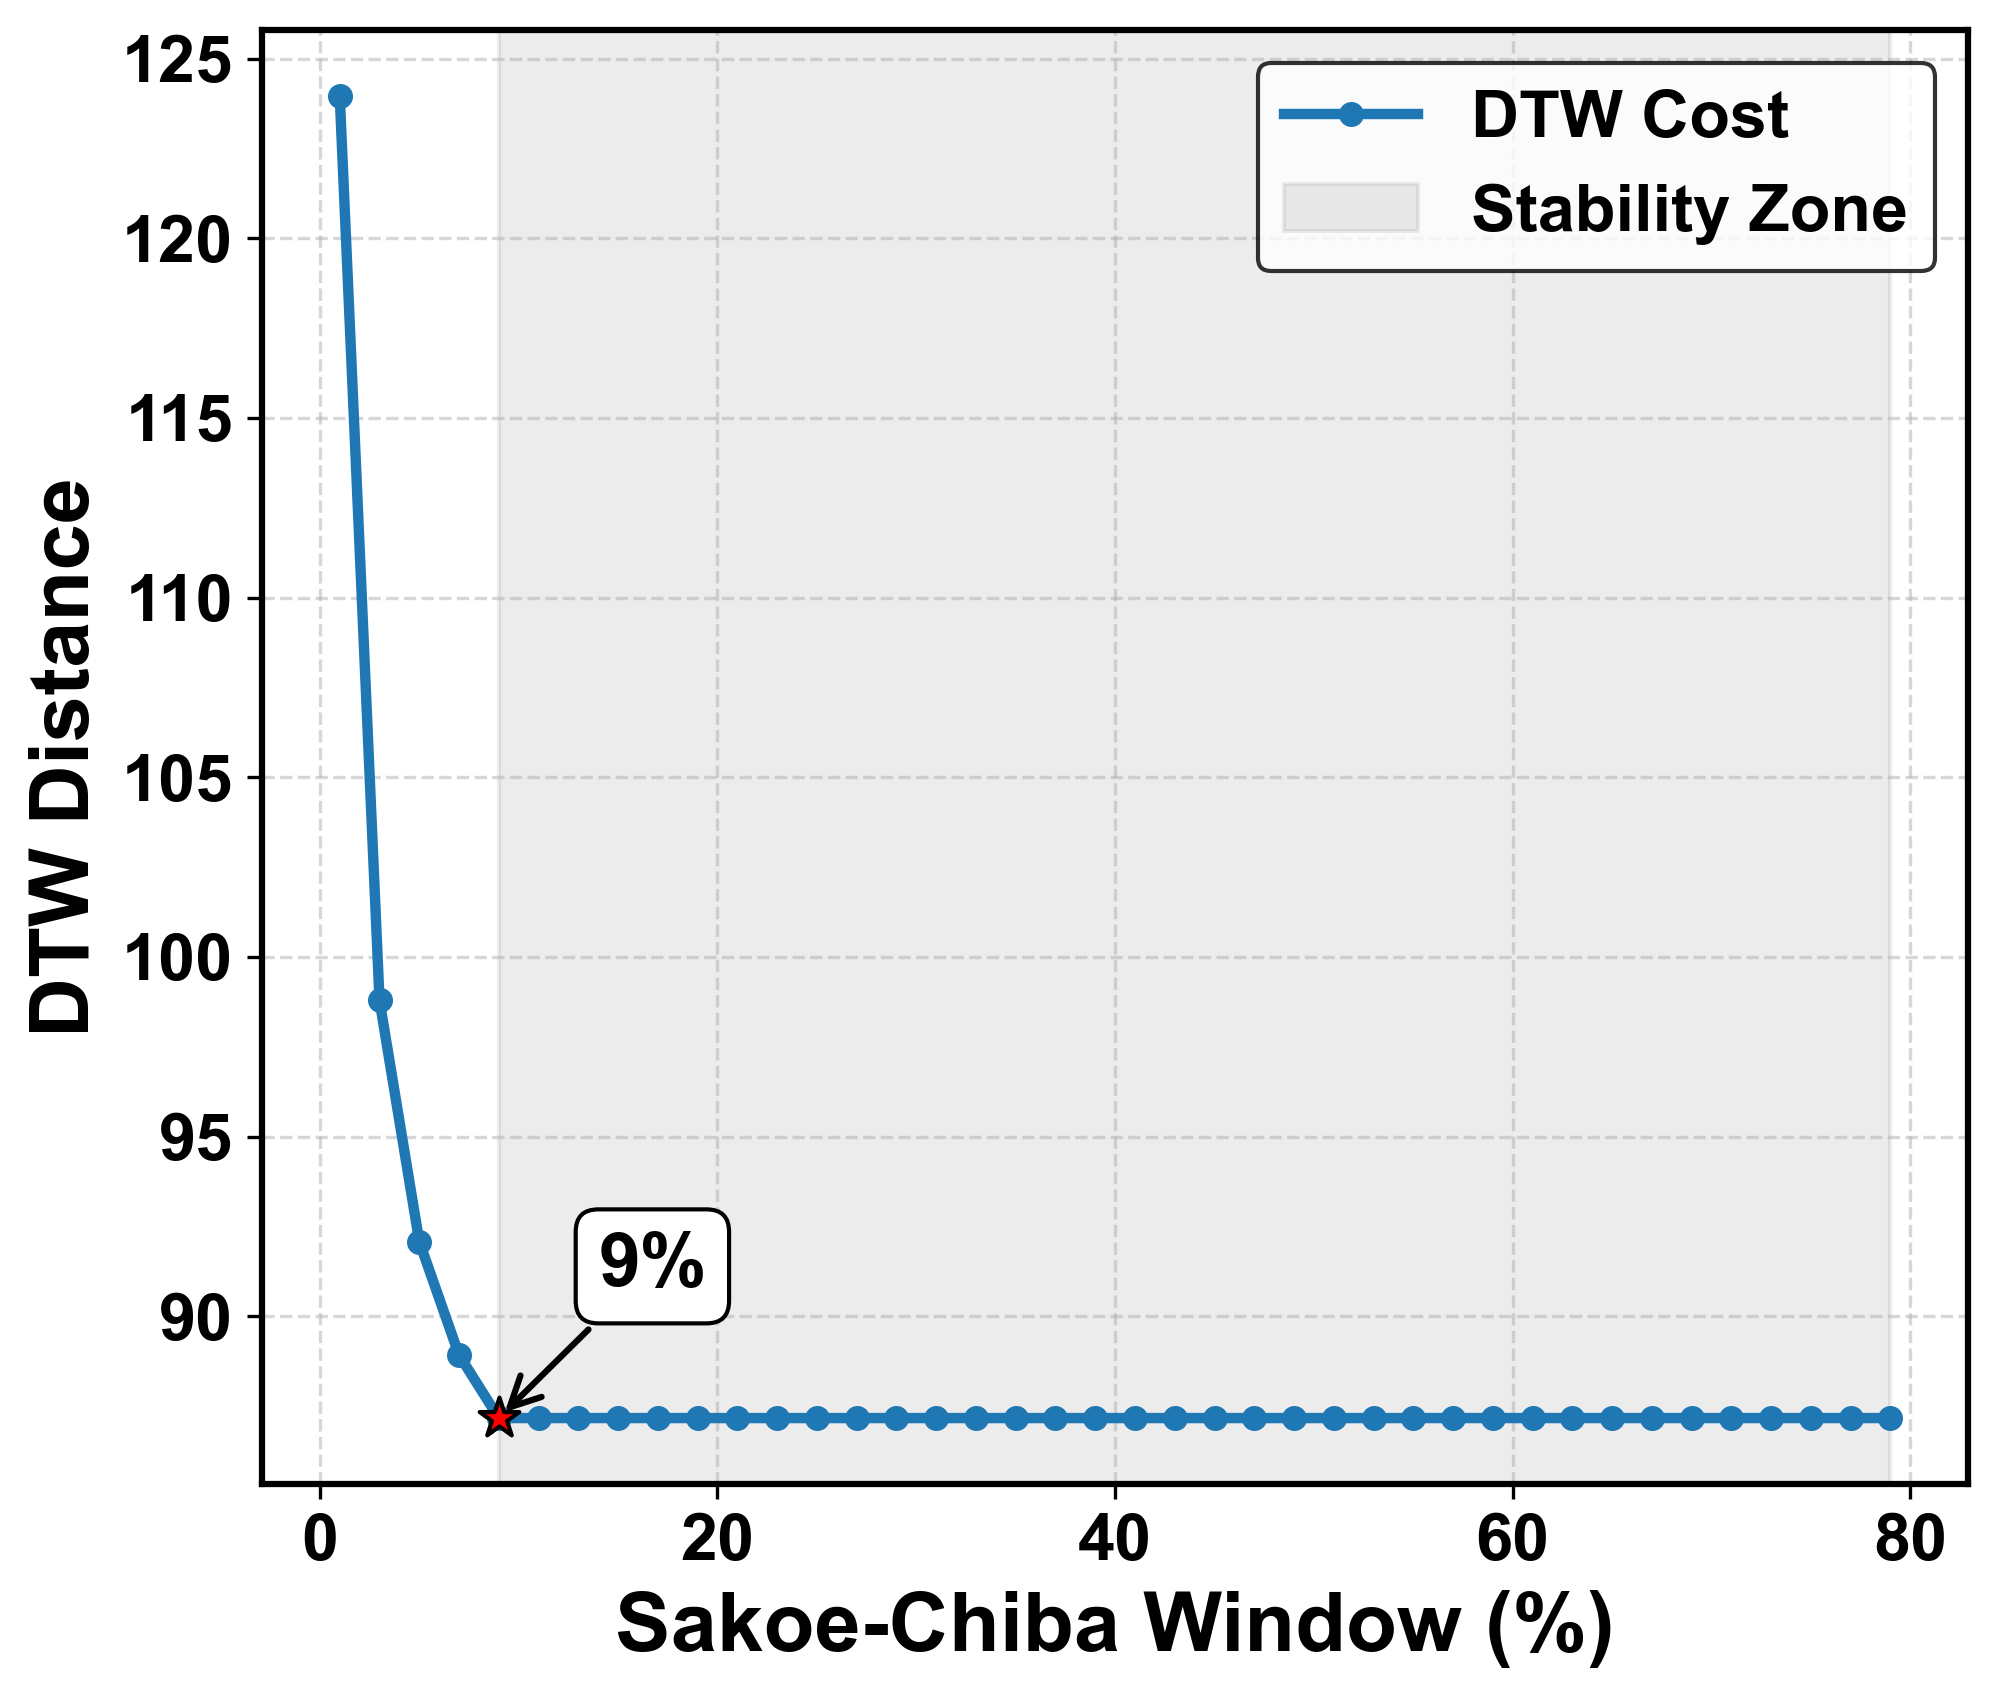

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# 1. MATCHING GLOBAL STYLE FROM THE FIRST PLOT
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_research_l_curve_modified(window_percents, distances, label, log_name):
    # Find the optimum point
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    # Use the smaller figsize from the first code (7x6)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Main curve
    ax.plot(window_percents, distances, color='#1f77b4', lw=2.5, 
            marker='o', ms=5, label='DTW Cost')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point (Red Star)
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=100, marker='*', zorder=10)
    
    # Annotation - Matching the first plot's clean style
    # We use a simpler straight arrow and tighter box
    ax.annotate(f'{round(best_window)}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances)-min_dist)*0.1),
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
                weight='bold')
    # Labels (Matching first code)
    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("DTW Distance")

    # Legend - Cleaned up to match first plot
    leg = ax.legend(loc='upper right', frameon=True)
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight('bold')

    leg = ax.legend(loc='upper right', frameon=True)
    for text in leg.get_texts():
        text.set_fontweight('bold')
    leg.get_frame().set_edgecolor('black')

    # Grid
    ax.grid(True, linestyle='--', alpha=0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')
    # Remove the title if you want it exactly like the first screenshot, 
    # or keep it if needed for the paper:
    # ax.set_title(f'Optimization: {label}', pad=15)

    plt.tight_layout()
    plt.savefig(f"{label}_GR_Lcurve.jpg", bbox_inches='tight', pad_inches=0.02)
    plt.show()

# --- EXECUTION ---
label = "J5-172" 
y_values = all_results[label]
x_values = np.linspace(1, 79, len(y_values)).tolist()

plot_research_l_curve_modified(x_values, y_values, label, "Gamma Ray")

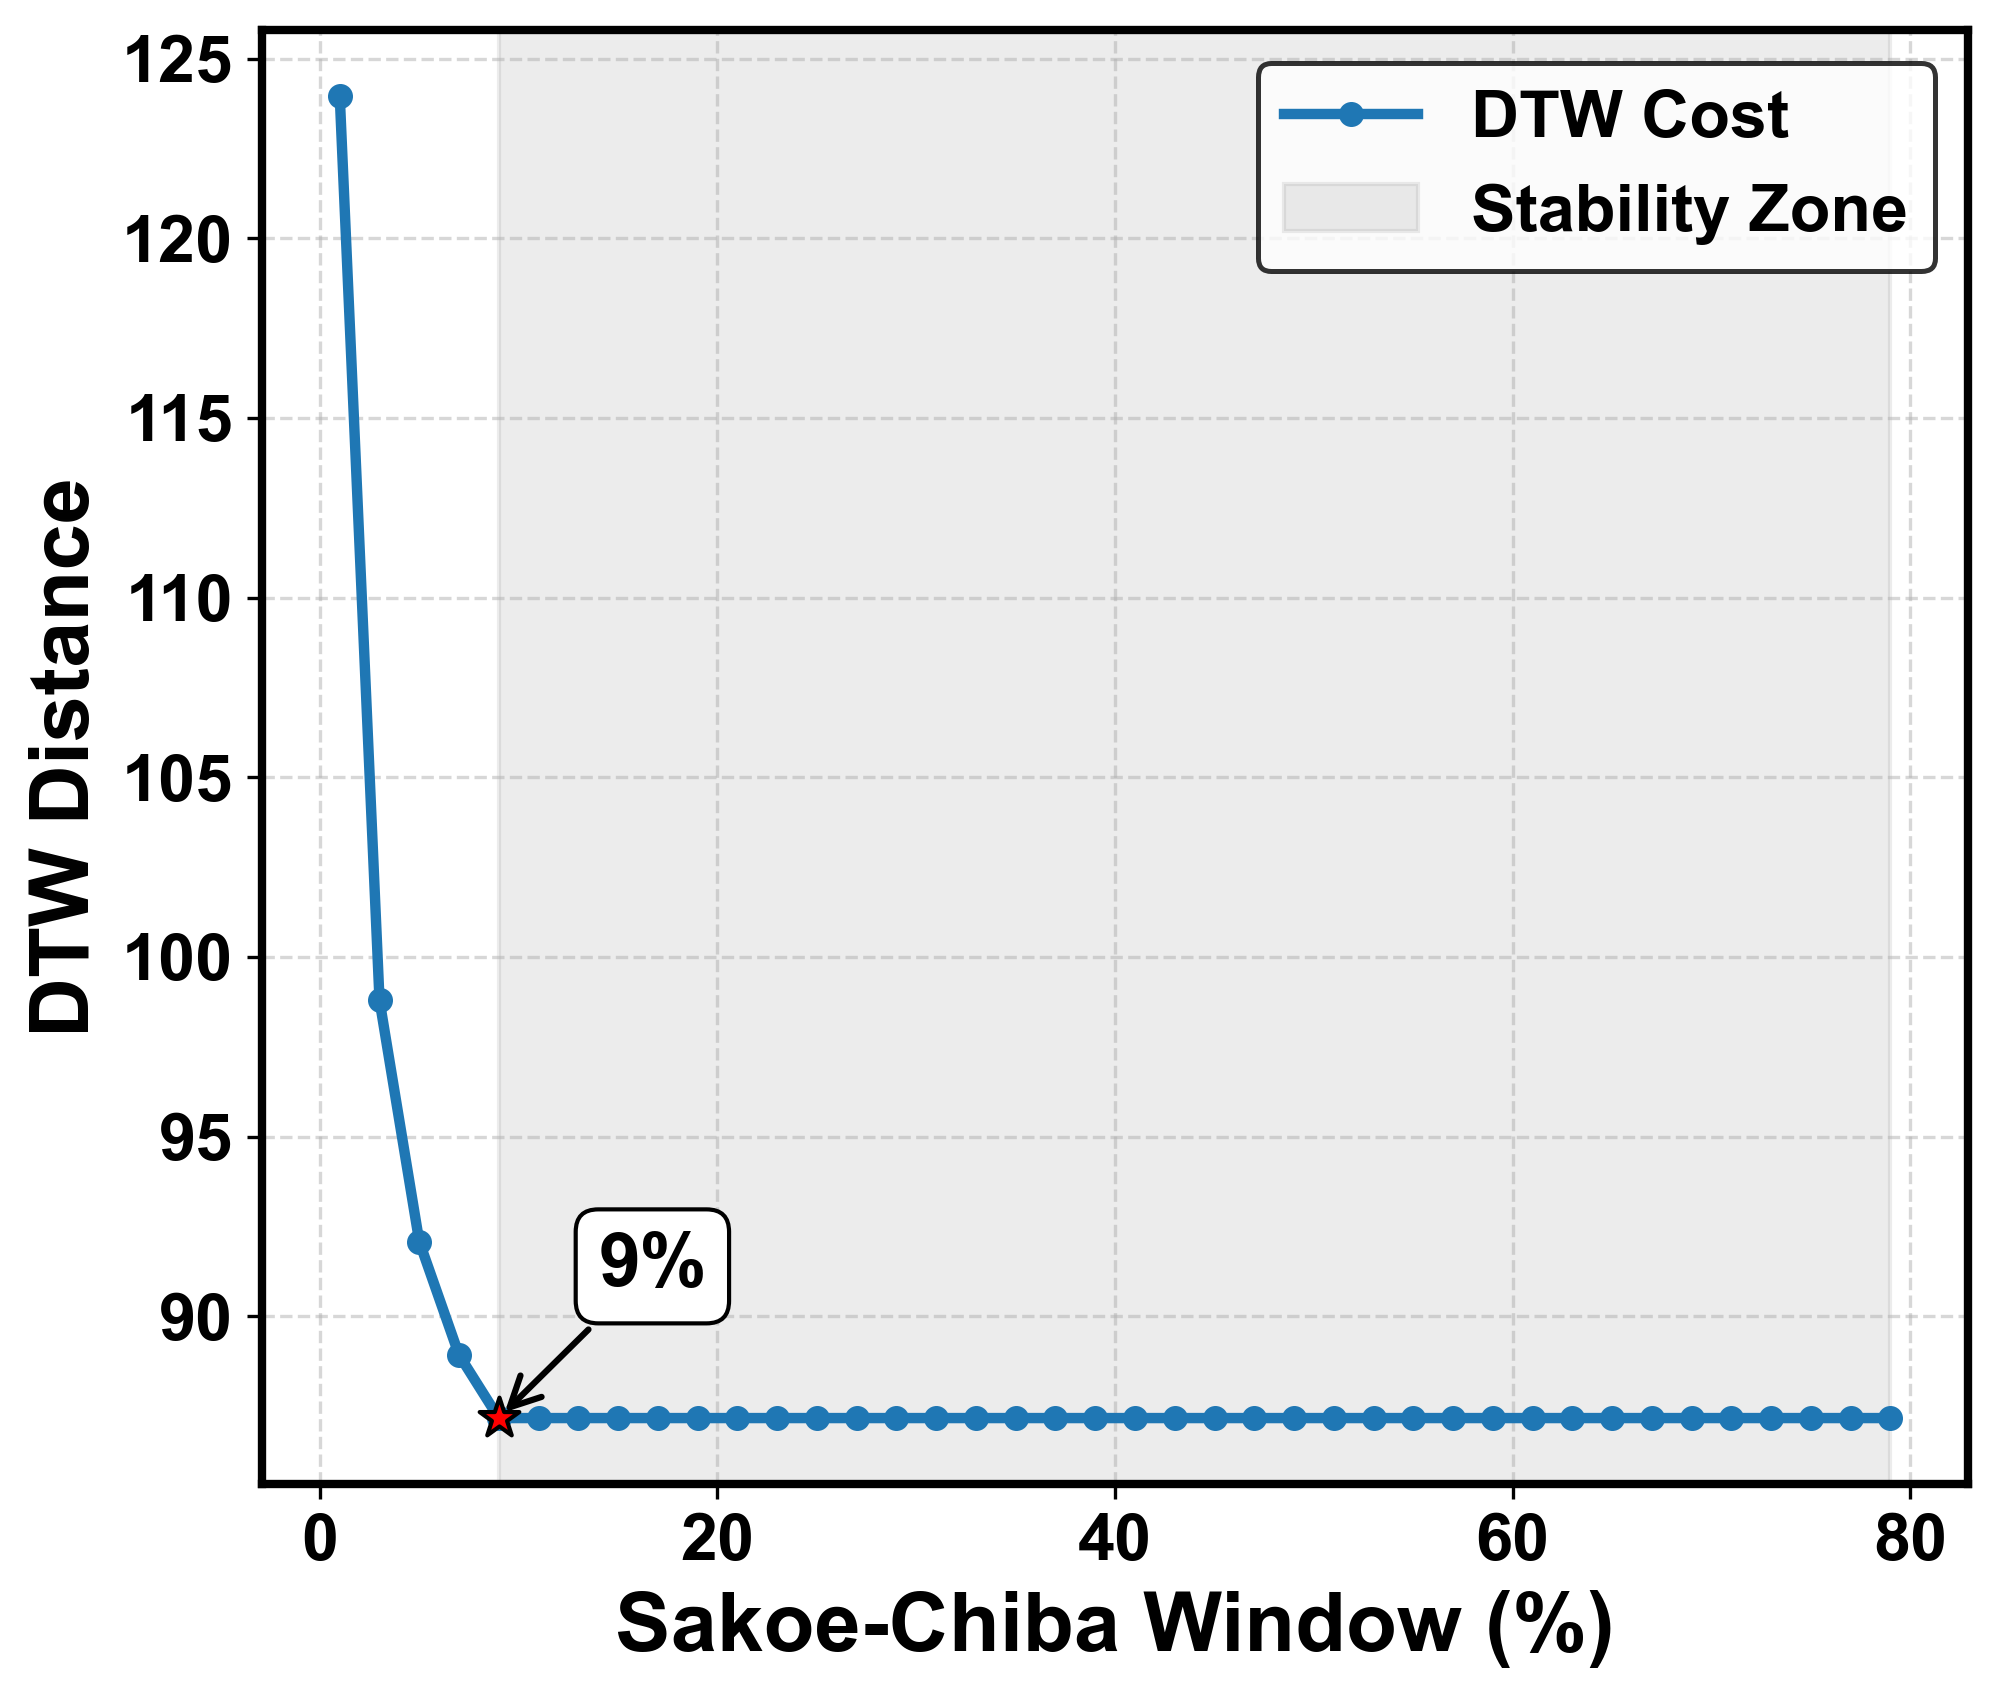

In [92]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# 1. RC PARAMETERS
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_research_l_curve_final(window_percents, distances, label):
    min_dist = min(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    fig, ax = plt.subplots(figsize=(7, 6))

    # Main curve
    ax.plot(window_percents, distances, color='#1f77b4', lw=2.5, 
            marker='o', ms=5, label='DTW Cost')
    
    # Stability zone
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')
    
    # Optimum point
    ax.scatter(best_window, min_dist, color='red', edgecolor='black', 
               s=100, marker='*', zorder=10)
    
    # Annotation
    ax.annotate(f'{round(best_window)}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 5, min_dist + (max(distances)-min_dist)*0.1),
                weight='bold',
                arrowprops=dict(arrowstyle='->', lw=1.5),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

    # Labels
    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("DTW Distance")

    # --- FORCE INTEGER Y-TICKS ---
    # This formatter explicitly converts the float value to an integer string
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(round(x))}'))
    
    # Make tick labels bold
    for label_obj in ax.get_xticklabels() + ax.get_yticklabels():
        label_obj.set_fontweight('bold')

    # Legend with bold text
    leg = ax.legend(loc='upper right', frameon=True)
    for text in leg.get_texts():
        text.set_fontweight('bold')
    
    leg.get_frame().set_edgecolor('black')
    leg.get_frame().set_linewidth(1.2)

    ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{label}_GR_Lcurve_Integer.jpg", bbox_inches='tight', pad_inches=0.02)
    plt.show()

# --- EXECUTION ---
label = "J5-172" 
y_values = all_results[label]
x_values = np.linspace(1, 79, len(y_values)).tolist()

plot_research_l_curve_final(x_values, y_values, label)

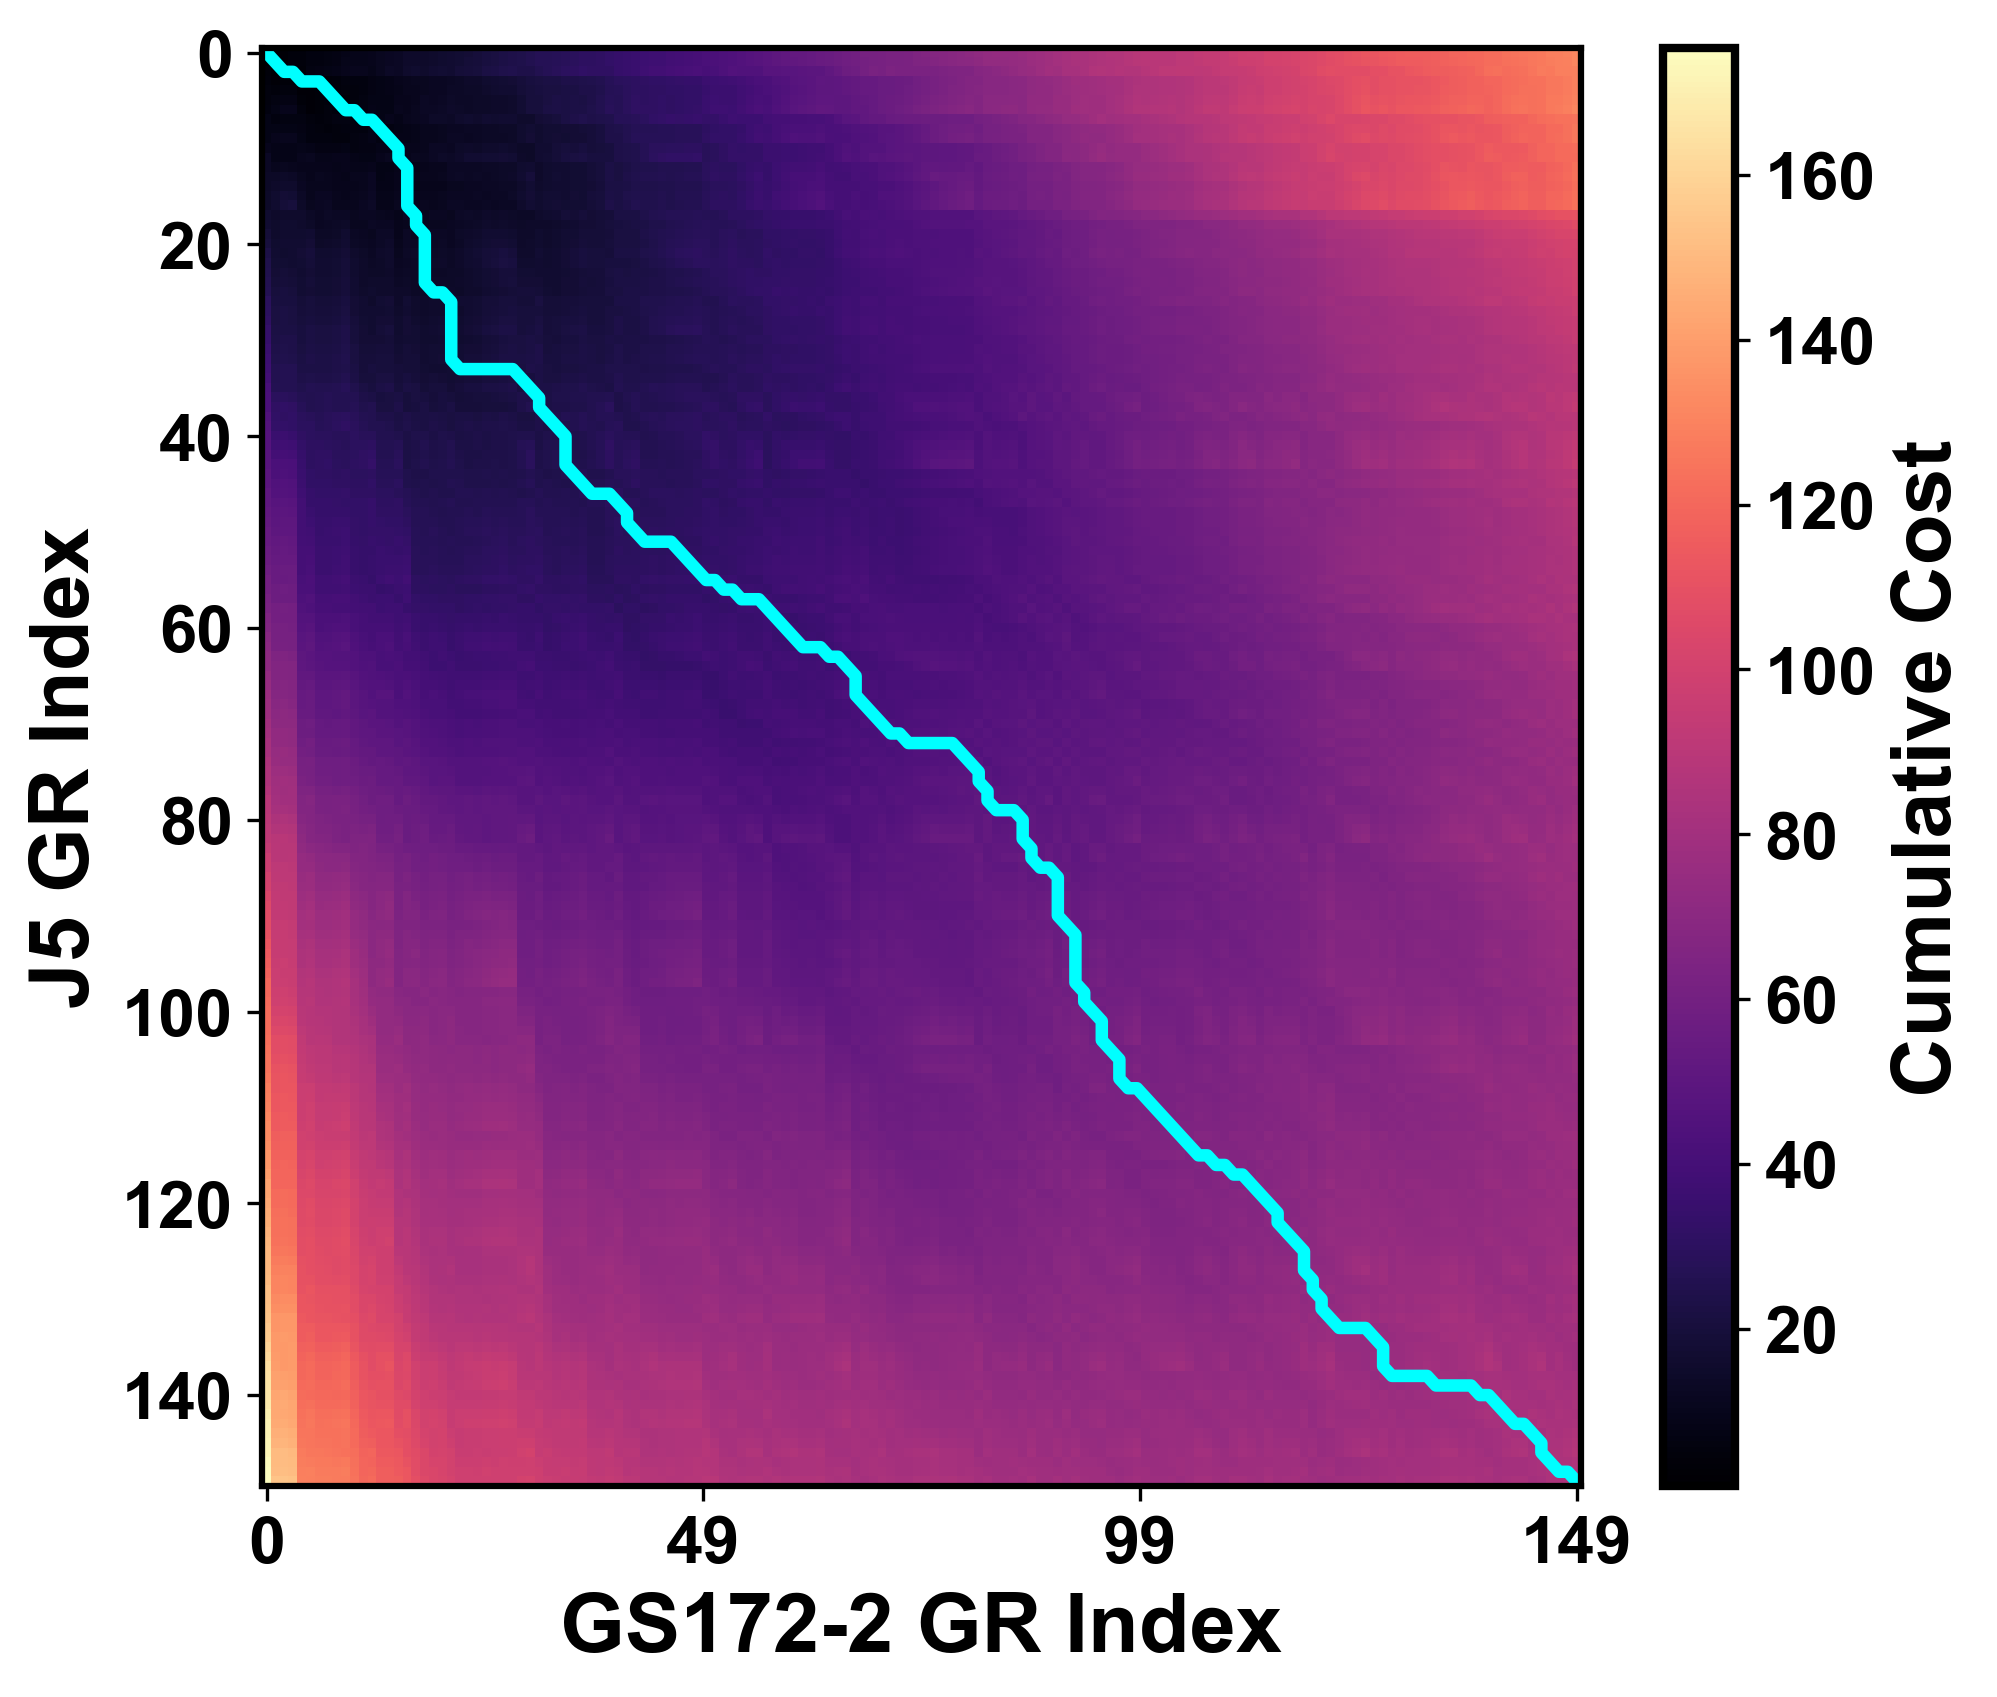

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_dtw_full_matrix_styled(df1, df2, label1, label2):
    # Standardize logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()

    n, m = len(s1), len(s2)

    # DTW matrix (Full matrix calculation, no windowing)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0,0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i,j] = cost + min(
                dtw_matrix[i-1,j],
                dtw_matrix[i,j-1],
                dtw_matrix[i-1,j-1]
            )

    # Backtracking
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i-1, j-1))
        steps = [dtw_matrix[i-1,j-1], dtw_matrix[i-1,j], dtw_matrix[i,j-1]]
        move = np.argmin(steps)
        if move == 0:
            i, j = i-1, j-1
        elif move == 1:
            i -= 1
        else:
            j -= 1

    path = np.array(path[::-1])

    # Visualization (7x6 figsize to match plot 1)
    fig, ax = plt.subplots(figsize=(7,6))

    matrix = dtw_matrix[1:, 1:]
    img = ax.imshow(matrix.T, origin='upper', cmap='magma', aspect='auto')

    # Path (Matching color and width)
    ax.plot(path[:,0], path[:,1], color='cyan', linewidth=3)

    # Labels (Matching first plot style)
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")

    # Set X-ticks (4 ticks for clarity like requested in first code)
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # Bold tick labels
    for label_obj in ax.get_xticklabels() + ax.get_yticklabels():
        label_obj.set_fontweight('bold')

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", weight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    ax.grid(False)

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    plt.savefig(f"{label1}_{label2}_FullWarping.jpg", bbox_inches='tight')
    plt.show()

# --- CALL ---
plot_dtw_full_matrix_styled(df_172, df_j5, "GS172-2", "J5")

Plot saved to: L_curve/GS172-2_J5_Correlation_Final.jpg


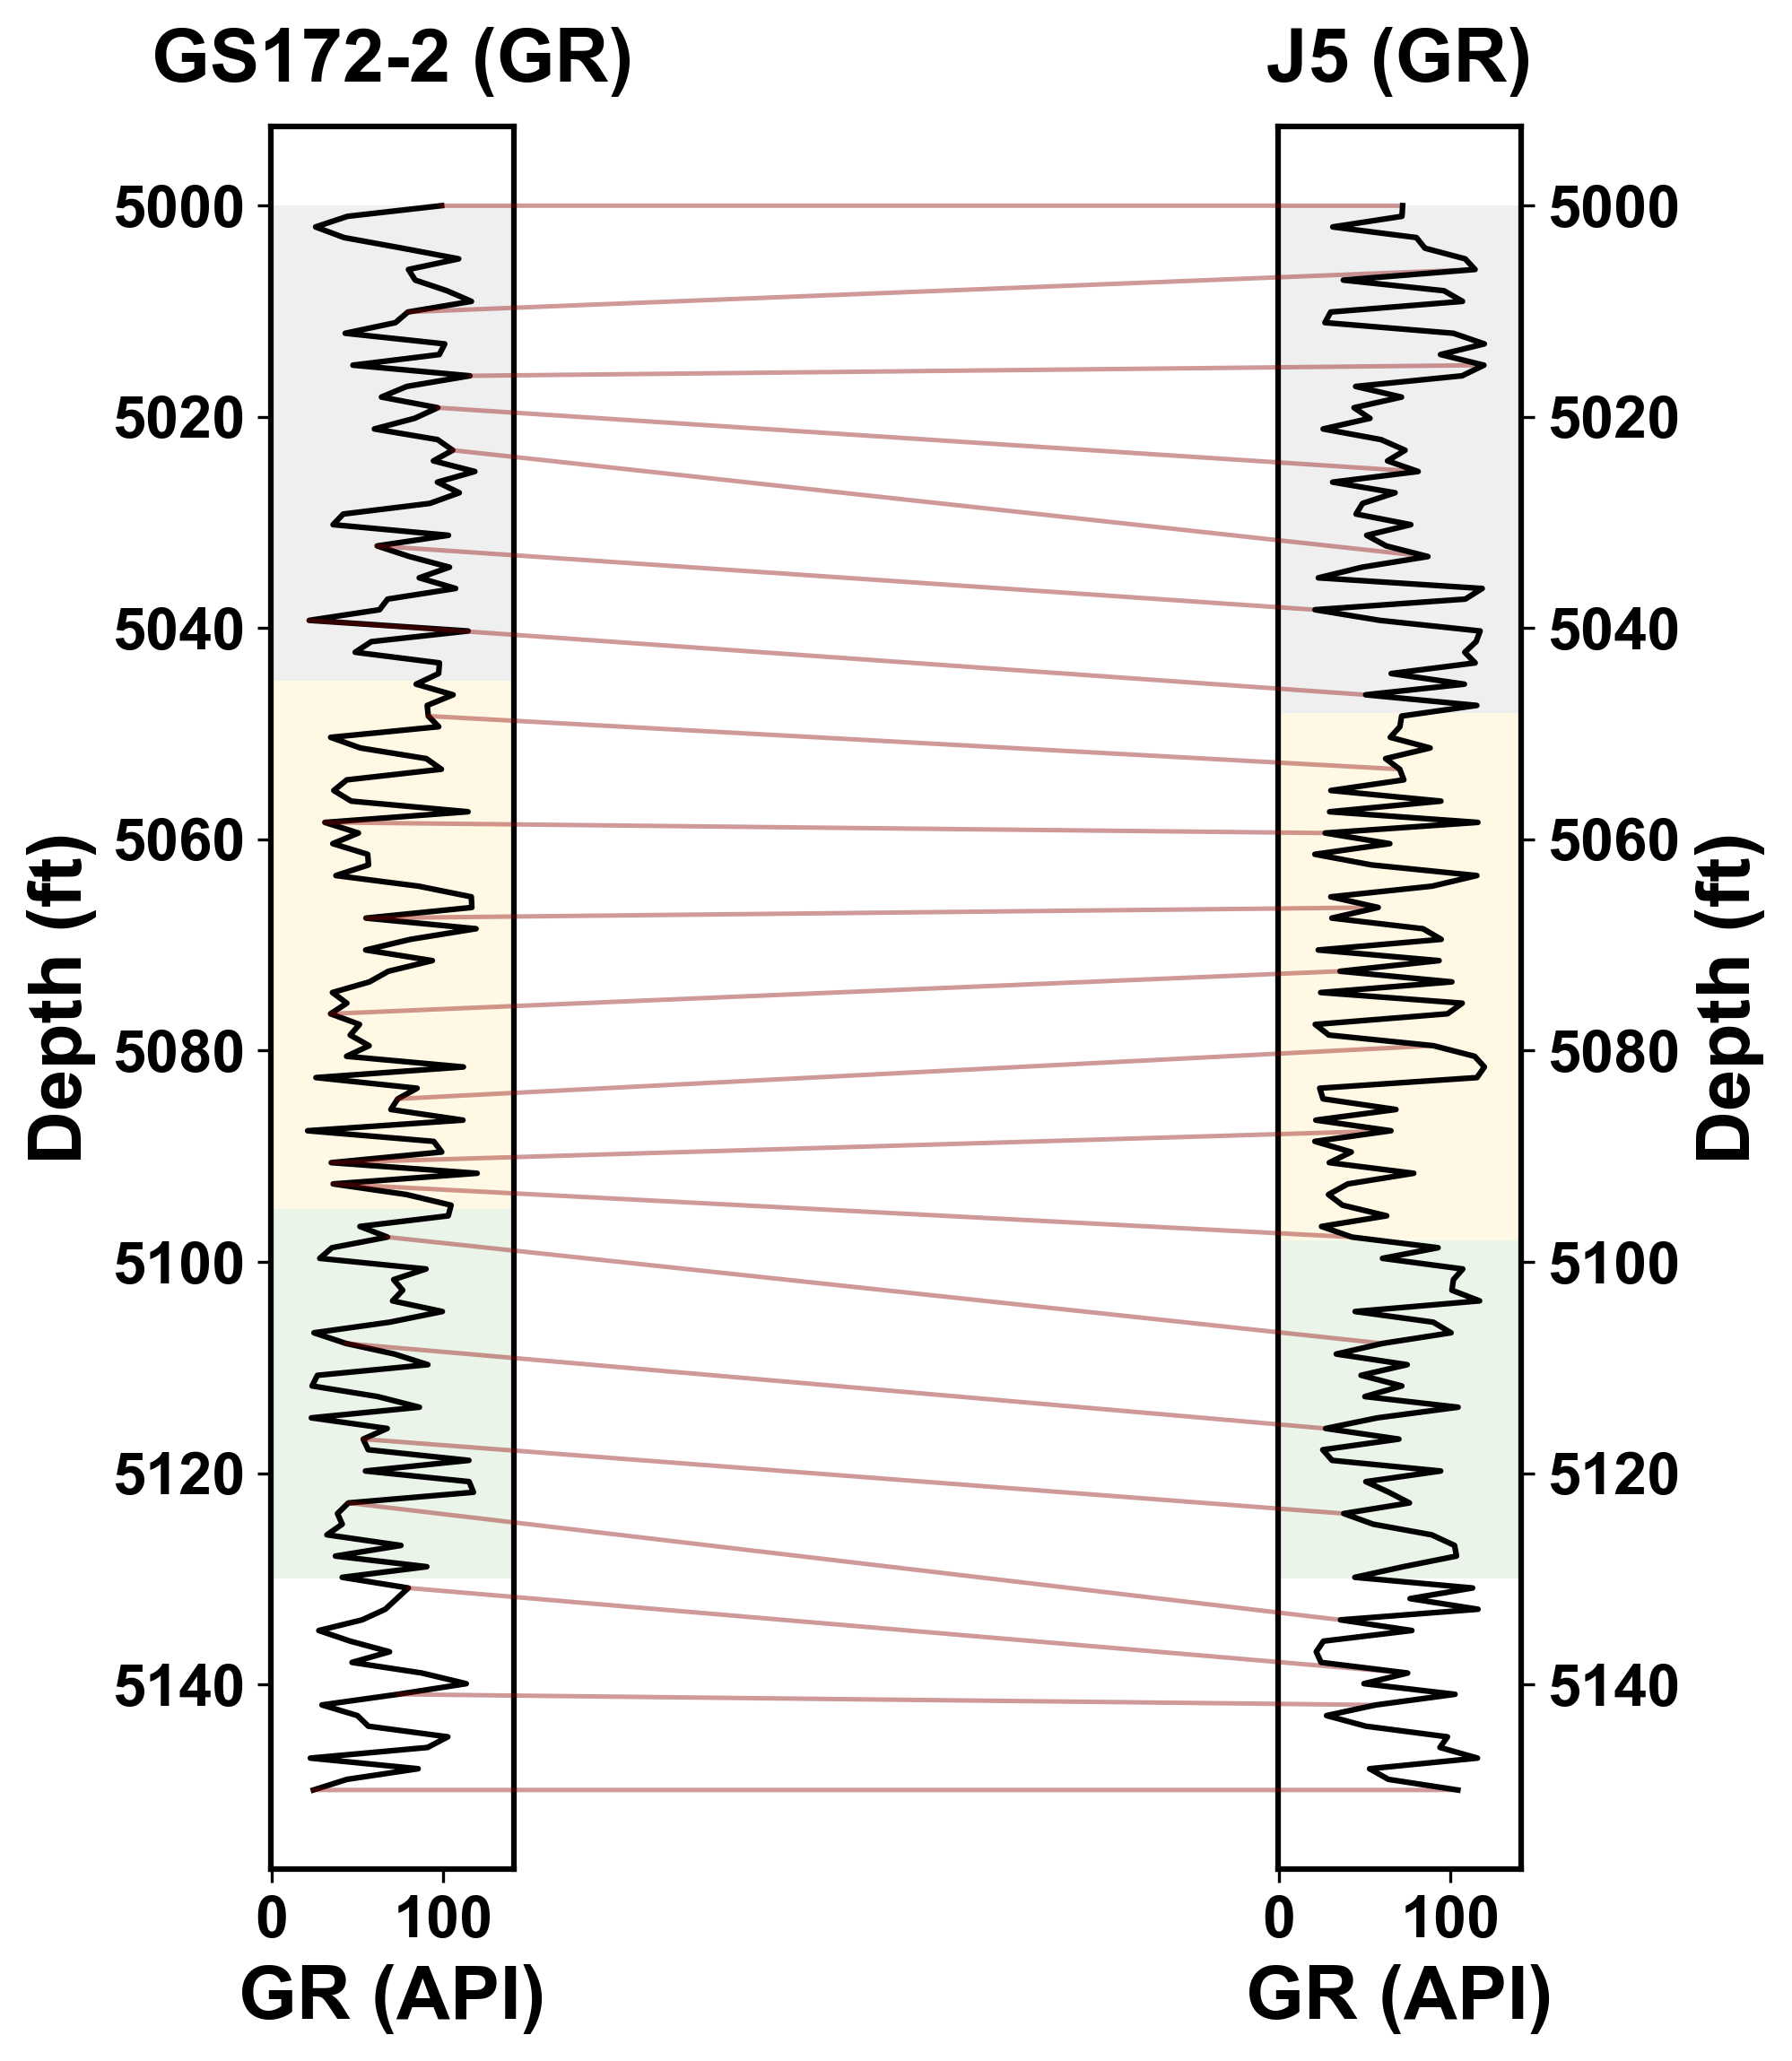

In [109]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler

# 1. MATCHING GLOBAL STYLE (ARIAL + CLEAN FONT SIZES)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_well_correlation_final_styled(df1, df2, zones1, zones2, label1, label2, window_p):
    # Standardize GR logs for DTW
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    # Get DTW path
    path = dtw_with_path(s1, s2, window_p)
    
    # 2. ADJUSTED FIGURE SIZE (Matching the first plot 7x8 ratio)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # LOG LINE (lw=1.5 like the first code)
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12)
        ax.set_xlabel("GR (API)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # BOLD TICKS
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (FIXED: Using facecolor to remove matplotlib warning)
        for z_name, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # WIDEN WELL BOX (Logic from first code)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # SPINES / BORDERS
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

        ax.grid(False)

    # 3. CORRELATION LINES (MATCH FIRST PLOT DENSITY)
    # --- FIX 2: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10 
    for idx in range(0, len(path), line_density_step):
        idx1, idx2 = path[idx]

        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 1]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 1]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", alpha=0.4, lw=1.2, zorder=4
        )
        axes[1].add_artist(con)

    plt.tight_layout()
    
    # Save as high-res JPG
    if not os.path.exists('L_curve'): 
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_Correlation_Final.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.05)
    print(f"Plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
# --- FIX 3: Passed the dummy zone arrays and your execution window parameter ---
plot_well_correlation_final_styled(df_172, df_j5, zones_gs172, zones_j5, "GS172-2", "J5", 0.09)

## for nphi

L-Curve optimized plot saved to: L_curve/GS172-2_J5_LCURVE_NPHI.jpg


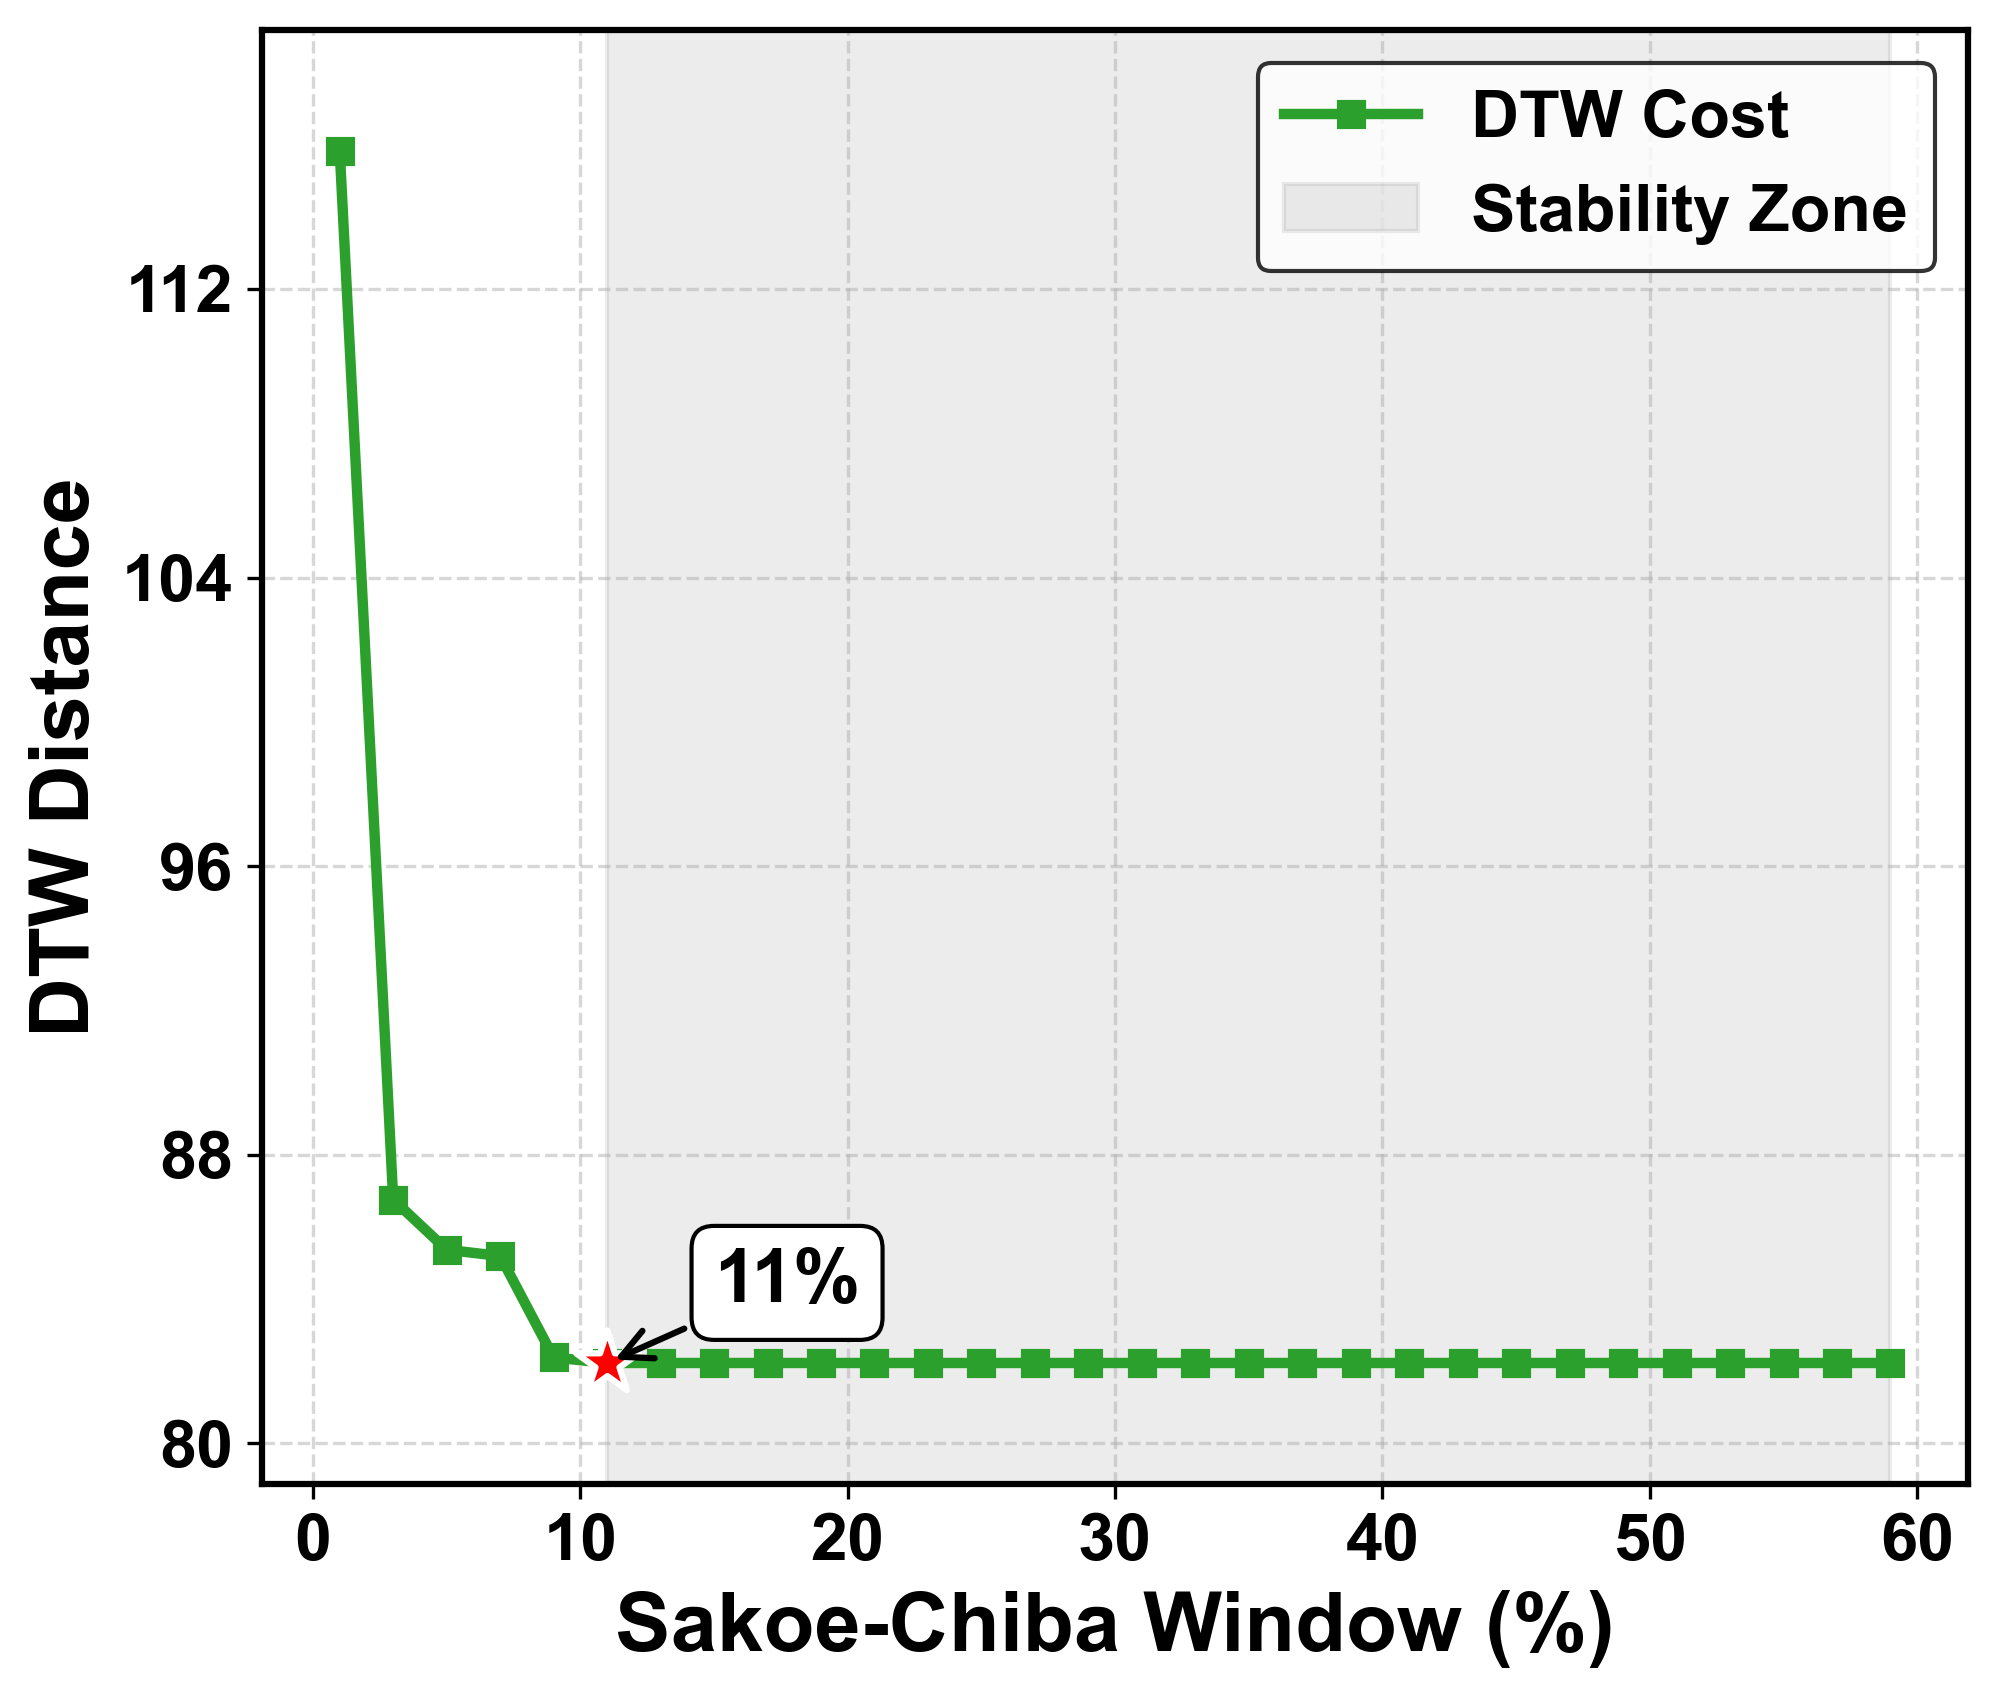

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator
from matplotlib.ticker import MaxNLocator

# 1. STYLE CONFIGURATION (MATCHING TARGET PLOTS)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_research_l_curve_refined(window_percents, distances, label, log_name):
    min_dist = min(distances)
    max_dist = max(distances)
    best_idx = distances.index(min_dist)
    best_window = window_percents[best_idx]
    
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot line and stability zone
    ax.plot(window_percents, distances, color='#2ca02c', lw=2.5, 
            marker='s', ms=6, label='DTW Cost', zorder=10)
    ax.axvspan(best_window, max(window_percents), color='gray', 
               alpha=0.15, label='Stability Zone')

    # Optimum point marker
    ax.scatter(best_window, min_dist, color='red', edgecolor='white',
               linewidth=1.5, s=250, marker='*', zorder=20)
    
    # Dynamic Annotation padding based on the data span
    y_span = max_dist - min_dist if max_dist != min_dist else 1.0
    ax.annotate(f'{round(best_window)}%',
                xy=(best_window, min_dist),
                xytext=(best_window + 4, min_dist + (0.05 * y_span)), 
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
                weight='bold', zorder=25)

    ax.set_xlabel("Sakoe-Chiba Window (%)")
    ax.set_ylabel("DTW Distance")

    # ✅ FIX: DYNAMIC LIMITS (Adapts automatically to NPHI cost scale)
    padding = 0.1 * y_span if y_span > 0 else 0.5
    ax.set_ylim(min_dist - padding, max_dist + padding)
    
    # Automatically determines clean, evenly distributed tick locations
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # Ensure all labels and legend are BOLD
    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontweight('bold')

    leg = ax.legend(loc='upper right', frameon=True)
    for text in leg.get_texts():
        text.set_fontweight('bold')
    leg.get_frame().set_edgecolor('black')

    ax.grid(True, linestyle='--', alpha=0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Save step matching your folder design
    if not os.path.exists('L_curve'): 
        os.makedirs('L_curve')
    save_path = f"L_curve/{label}_LCURVE_NPHI.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    
    print(f"L-Curve optimized plot saved to: {save_path}")
    plt.show()

# --- EXECUTION ---
label = "GS172-2_J5"
# Convert window constraints to decimal scaling percentages if needed
x_values = np.arange(1, 61, 2).tolist()
y_values = nphi_grid_results["J5-GS172"]

plot_research_l_curve_refined(x_values, y_values, label, "Neutron Porosity")

Bold plot saved to: L_curve/GS172-2_J5_NPHI_Warping_Matched_Bold.jpg


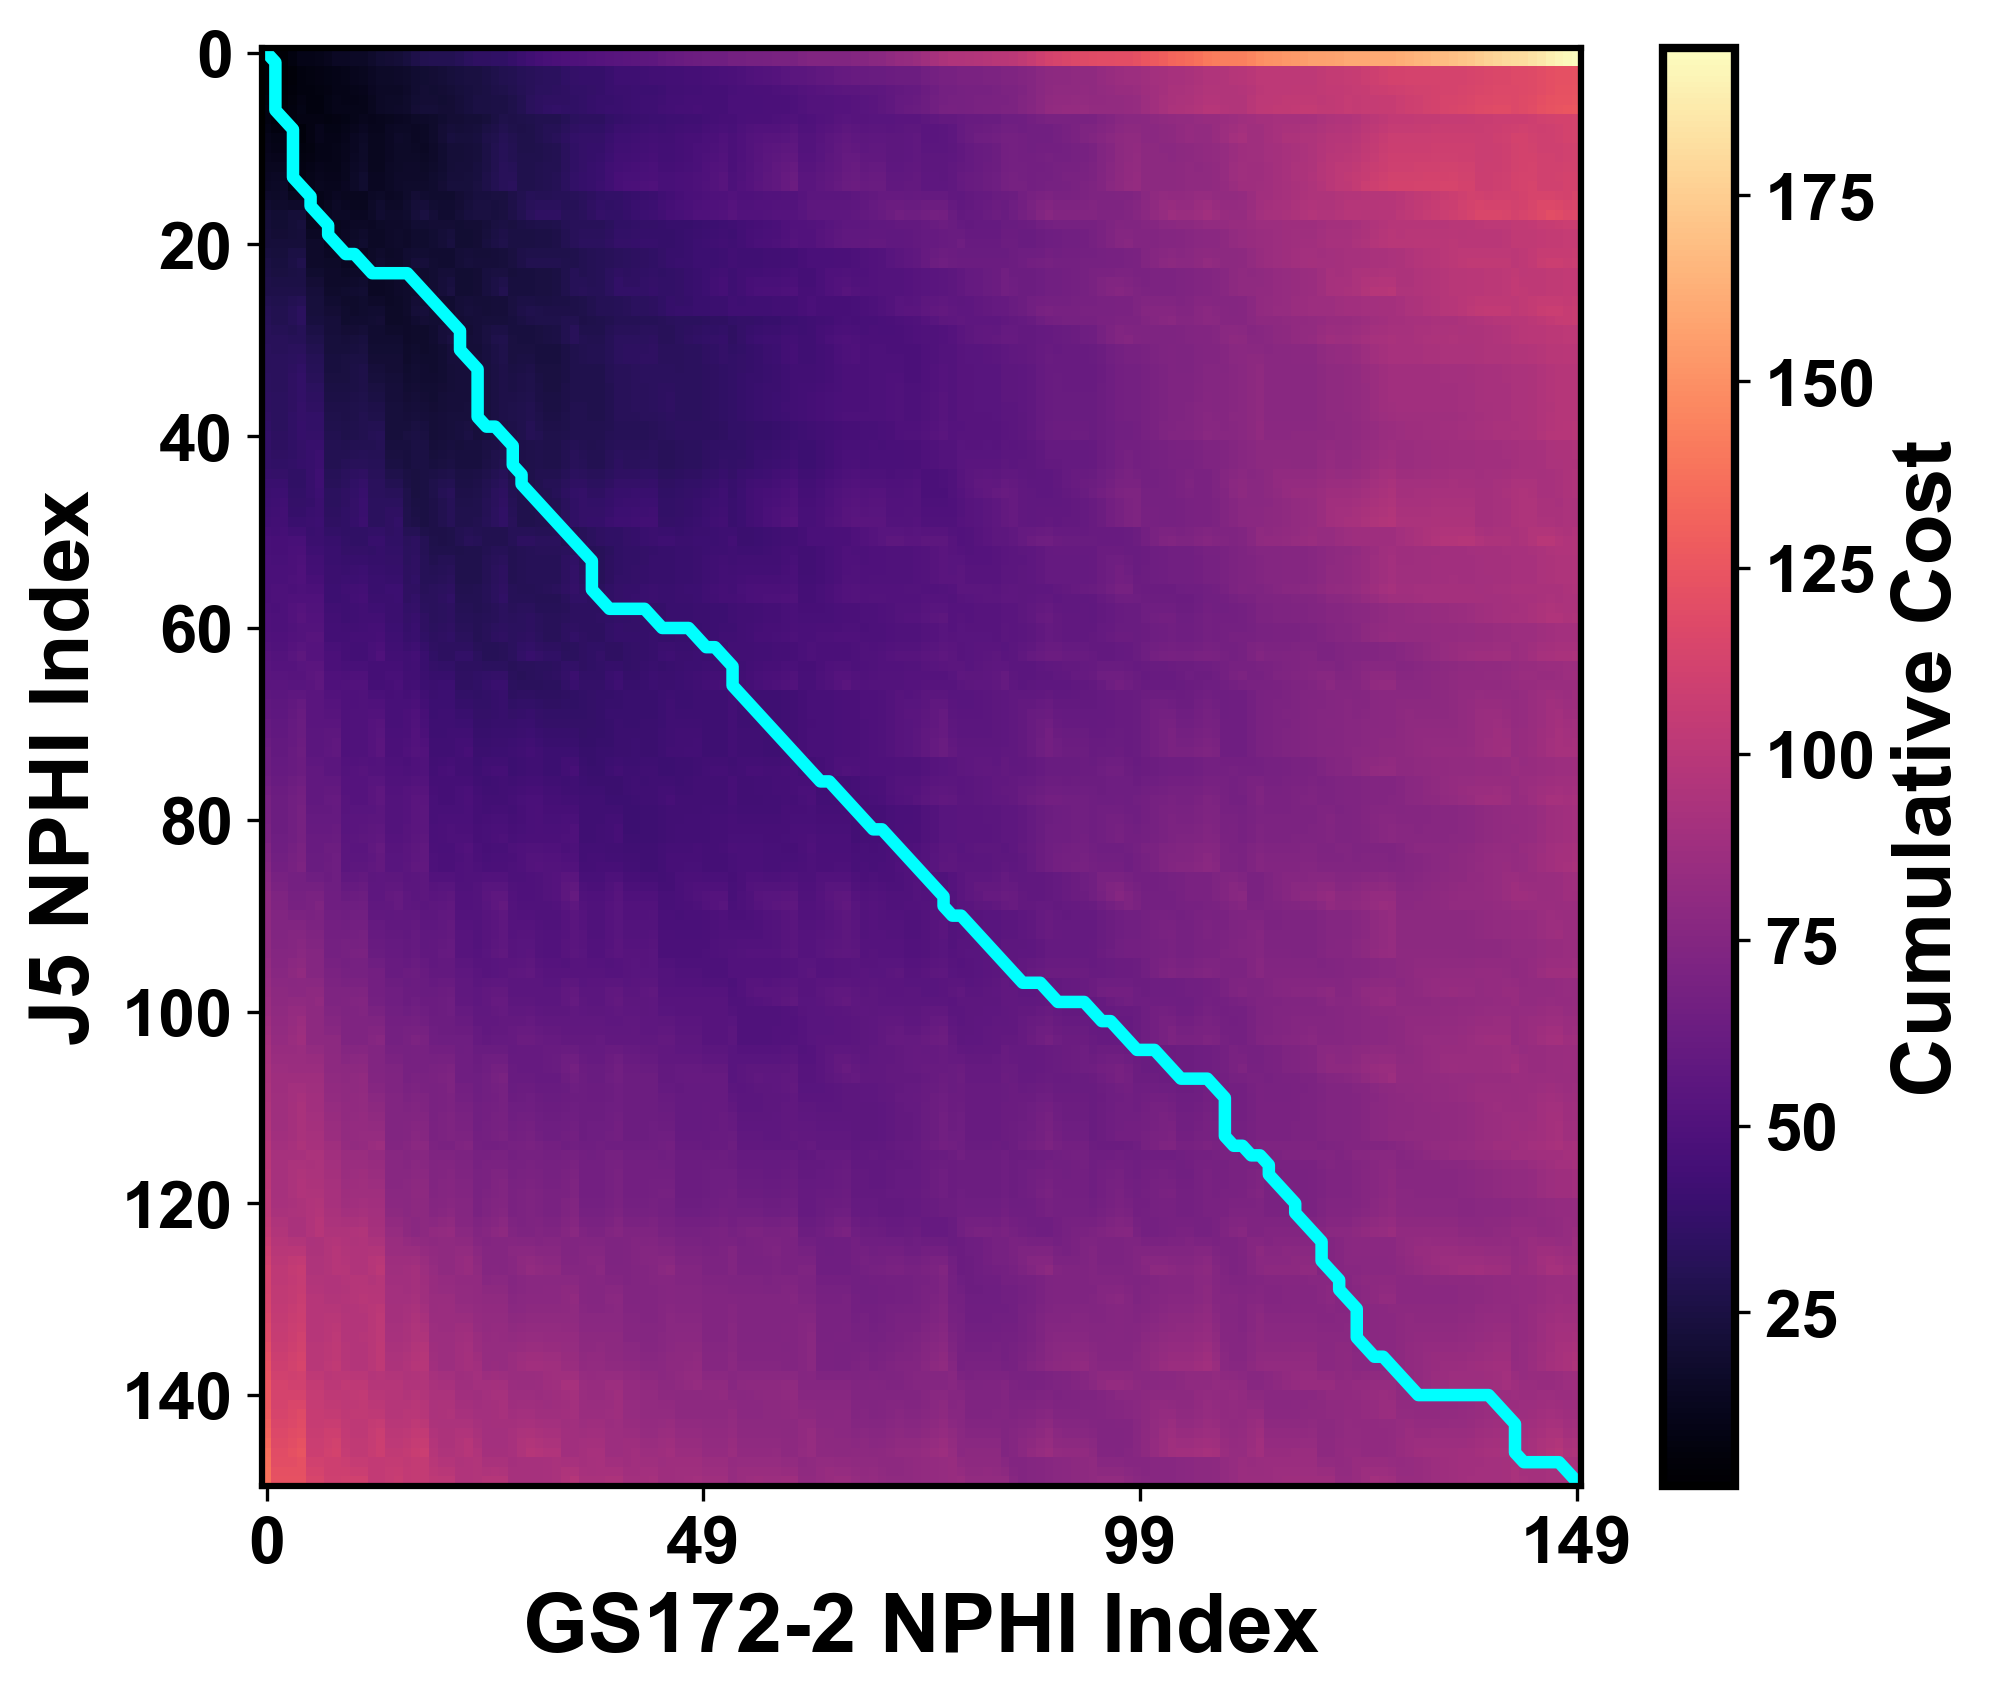

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt
import os

# Updated global parameters for bold axes and consistency
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_warping_GS172_matched_bold(df1, df2, label1, label2):
    # 1. Standardize NPHI logs
    scaler = StandardScaler()
    n1_smooth = medfilt(df1.iloc[:, 2].values, kernel_size=3)
    n2_smooth = medfilt(df2.iloc[:, 2].values, kernel_size=3)
    
    s1 = scaler.fit_transform(n1_smooth.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(n2_smooth.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. FULL DTW matrix calculation
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(
                dtw_matrix[i-1, j],
                dtw_matrix[i, j-1],
                dtw_matrix[i-1, j-1]
            )

    # 3. Backtracking for optimal path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        step = np.argmin([dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]])
        if step == 0:
            i, j = i-1, j-1
        elif step == 1:
            i -= 1
        else:
            j -= 1
    path = np.array(path[::-1])

    # 4. Visualization (7x6 size)
    fig, ax = plt.subplots(figsize=(7, 6))

    matrix = dtw_matrix[1:, 1:]
    img = ax.imshow(matrix.T, origin='upper', cmap='magma', aspect='auto')

    # Path plotting in cyan
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Labels (Removed titles above individual blocks)
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")

    # Tick Density Adjustment
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # ✅ BOLD TICKS: Explicitly setting tick label weight
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight('bold')

    # Colorbar configuration
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost", fontweight='bold')
    # Bold colorbar tick labels
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    # Spines & Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Save Logic
    if not os.path.exists('L_curve'):
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Warping_Matched_Bold.jpg"
    plt.savefig(save_path, bbox_inches='tight')

    print(f"Bold plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
plot_nphi_warping_GS172_matched_bold(df_172, df_j5, "GS172-2", "J5")

Styled plot saved to: L_curve/GS172-2_J5_NPHI_Correlation_Final.jpg


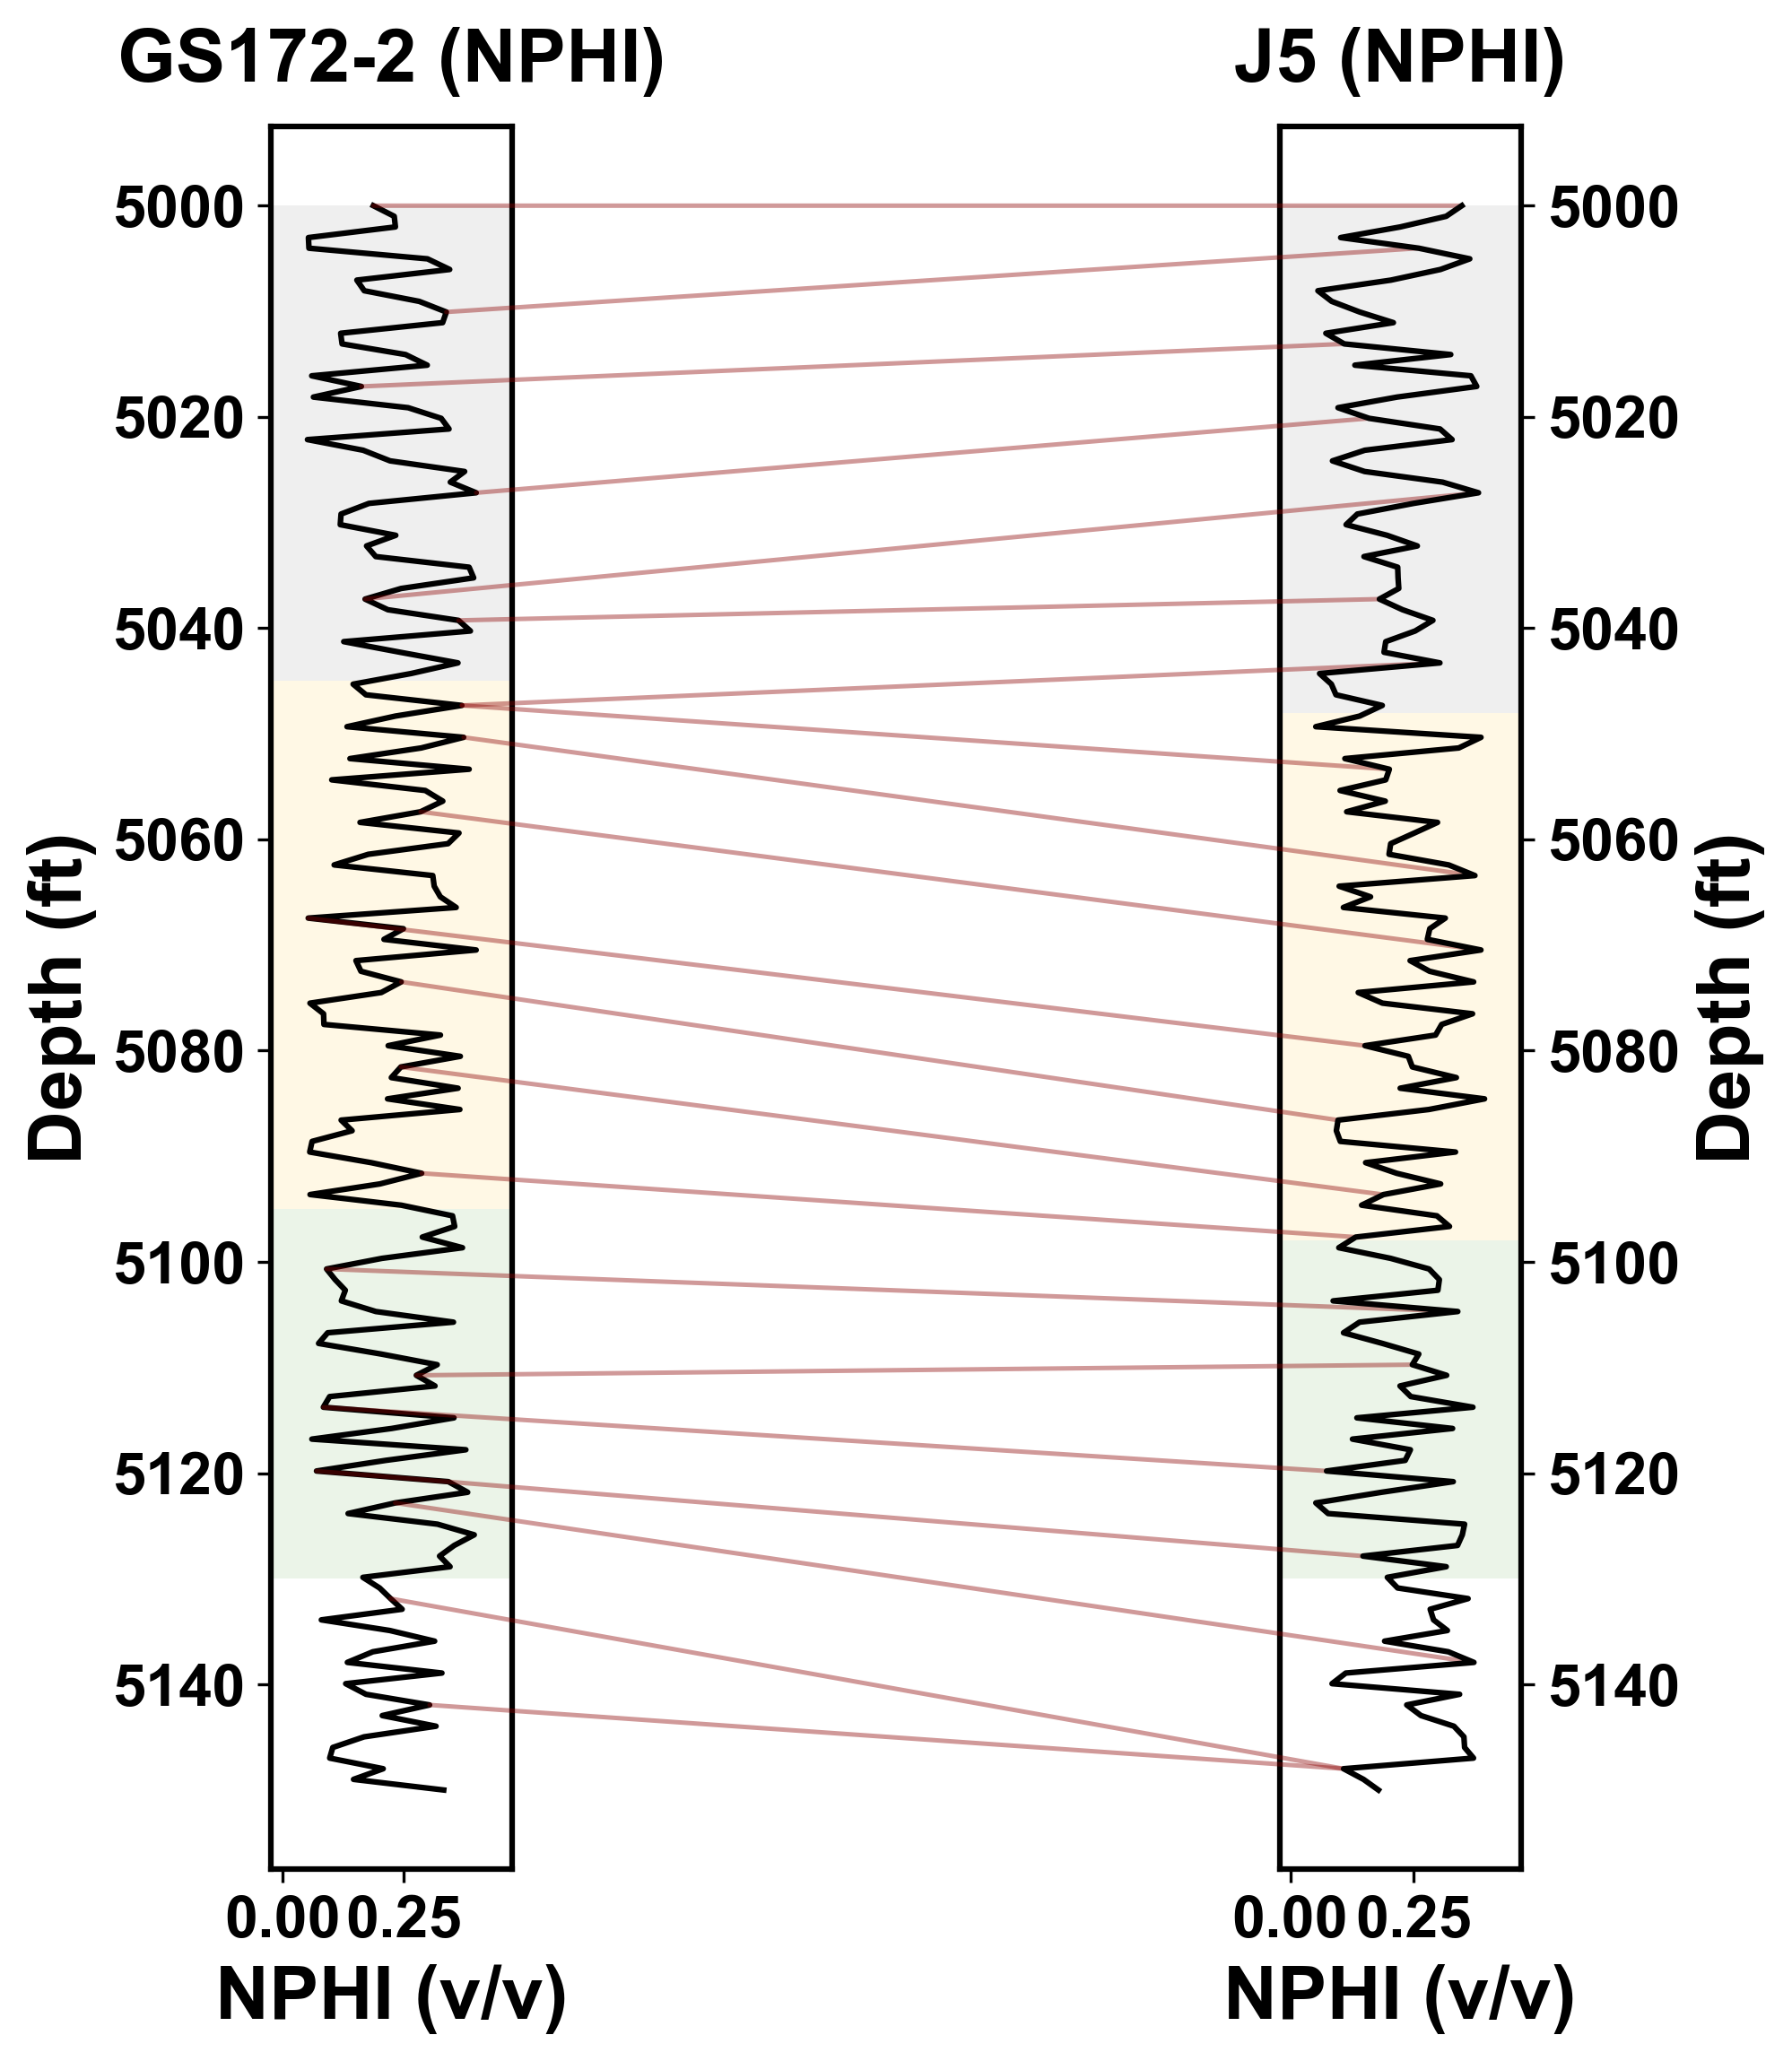

In [119]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler
from scipy.signal import medfilt

# 1. MATCHING GLOBAL STYLE (ARIAL + CLEAN FONT SIZES)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_correlation_styled(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize and smooth NPHI logs (using column index 2)
    scaler = StandardScaler()
    
    nphi1_smooth = medfilt(df1.iloc[:, 2].values, kernel_size=5)
    nphi2_smooth = medfilt(df2.iloc[:, 2].values, kernel_size=5)
    
    s1 = scaler.fit_transform(nphi1_smooth.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(nphi2_smooth.reshape(-1,1)).flatten()
    
    # 2. DTW path
    path = dtw_with_path(s1, s2, window_p)
    
    # 3. FIGURE SIZE (Matching the first plot 7x8 ratio)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2]

        # LOG LINE (lw=1.5 like the first code)
        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        
        ax.invert_yaxis()
        # ✅ FIX 2: Set explicit bold titles for both axes tracks
        ax.set_title(f"{name} (NPHI)", fontweight='bold', pad=12)

        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # TICKS BOLD
        for t in ax.get_xticklabels() + ax.get_yticklabels():
            t.set_fontweight('bold')

        # STRATIGRAPHIC ZONES (Using facecolor to handle matplotlib warnings)
        for z_name, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # WIDEN WELL BOX (Crucial for the "First Plot" look)
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # SPINES (BORDERS)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

        ax.grid(False)

    # 4. CORRELATION LINES 
    # --- FIX 3: Reduced step size from 120 to 10 for validation datasets ---
    line_density_step = 10 
    for idx in range(0, len(path), line_density_step):
        idx1, idx2 = path[idx]

        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 2]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 2]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", alpha=0.4, lw=1.2, zorder=4
        )
        axes[1].add_artist(con)

    plt.tight_layout()
    
    # SAVE AS HIGH-RES JPG
    if not os.path.exists('L_curve'): 
        os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_Correlation_Final.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.05)
    print(f"Styled plot saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
# --- FIX 4: Passed the dummy zone definitions and your 0.11 optimal window parameter ---
plot_nphi_correlation_styled(df_172, df_j5, zones_gs172_dummy, zones_j5_dummy, "GS172-2", "J5", 0.11)